In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Tropical Pacific and ENSO-Region Variability

## Research Question

How did sea surface temperature anomalies in the Niño 3.4 region change from 1982 to 2020?

In this notebook, I analyze tropical Pacific sea surface temperature variability using the NOAA OISST dataset. I focus on the Niño 3.4 region, a central tropical Pacific region commonly used to monitor ENSO variability. I use Xarray to load the data, subset the region, calculate regional SST anomalies, and visualize monthly and annual changes over time.

## Dataset

I use the NOAA Optimum Interpolated Sea Surface Temperature dataset from the LEAP Data Catalog. The dataset is stored as a Zarr dataset and can be opened directly with Xarray, so no manual download is required.

The main variable used in this notebook is `sst`, which represents daily sea surface temperature in degrees Celsius. I use data from 1982 to 2020 because these are complete years in the dataset.

In [3]:
store = "https://ncsa.osn.xsede.org/Pangeo/pangeo-forge/noaa_oisst/v2.1-avhrr.zarr"

ds = xr.open_dataset(store, engine="zarr", chunks={})
ds

<xarray.Dataset> Size: 241GB
Dimensions:  (time: 14532, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 116kB 1981-09-01T12:00:00 ... 2021-06-14T1...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    anom     (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    creator_email:              oisst-help@noaa.gov
    creator_url:                https://www.ncei.noaa.gov/
    date_created:               2020-05-08T19:05:13Z
    ...                         ...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    standard_name_vocabulary:   CF Standard Name Table (v40, 25 January 2017)
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    time_coverage_end:          1981-09-01T23:59:59Z
    time_coverage_start:        1981-09-01T00:00:00Z
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...

In [4]:
sst = ds["sst"].squeeze()
anom = ds["anom"].squeeze()

sst = sst.sel(time=slice("1982-01-01", "2020-12-31"))
anom = anom.sel(time=slice("1982-01-01", "2020-12-31"))

sst

<xarray.DataArray 'sst' (time: 14245, lat: 720, lon: 1440)> Size: 59GB
dask.array<getitem, shape=(14245, 720, 1440), dtype=float32, chunksize=(20, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 114kB 1982-01-01T12:00:00 ... 2020-12-31T1...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_max:  4500
    valid_min:  -300

## Study Region

The Niño 3.4 region is commonly used to monitor ENSO variability. It is located in the central tropical Pacific, from 5°S to 5°N and 170°W to 120°W. Since this dataset uses longitudes from 0 to 360 degrees, this corresponds to 190°E to 240°E.

In [5]:
nino34 = sst.sel(
    lat=slice(-5, 5),
    lon=slice(190, 240)
)

nino34_anom = anom.sel(
    lat=slice(-5, 5),
    lon=slice(190, 240)
)

nino34

<xarray.DataArray 'sst' (time: 14245, lat: 40, lon: 200)> Size: 456MB
dask.array<getitem, shape=(14245, 40, 200), dtype=float32, chunksize=(20, 40, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 114kB 1982-01-01T12:00:00 ... 2020-12-31T1...
  * lat      (lat) float32 160B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon      (lon) float32 800B 190.1 190.4 190.6 190.9 ... 239.4 239.6 239.9
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_max:  4500
    valid_min:  -300

## Figure 1: Example SST Map in the Niño 3.4 Region

First, I plot one example SST map for the Niño 3.4 region. This confirms that the data subset is correct and shows the spatial pattern of sea surface temperature in the central tropical Pacific.

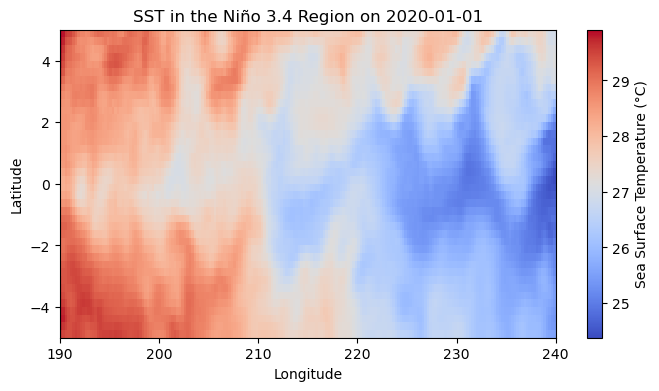

In [6]:
nino34_map = nino34.sel(time="2020-01-01").compute()

plt.figure(figsize=(8, 4))
nino34_map.plot(
    cmap="coolwarm",
    cbar_kwargs={"label": "Sea Surface Temperature (°C)"}
)

plt.title("SST in the Niño 3.4 Region on 2020-01-01")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

The map shows sea surface temperature in the Niño 3.4 region on one selected day. The purpose of this figure is to check that the spatial subset is correct and to show where the following time-series analysis is focused.

## Calculating Niño 3.4 SST Anomalies

To focus on variability instead of the normal seasonal cycle, I calculate monthly SST anomalies. I use the SST anomaly variable already included in the NOAA OISST dataset, then calculate the area-weighted mean anomaly for the Niño 3.4 region.

In [7]:
weights = np.cos(np.deg2rad(nino34_anom.lat))
weights.name = "weights"

nino34_anom_sample = nino34_anom.isel(time=slice(0, None, 30))

nino34_anomaly = nino34_anom_sample.weighted(weights).mean(dim=["lat", "lon"]).compute()

nino34_anomaly

<xarray.DataArray 'anom' (time: 475)> Size: 2kB
array([ 1.32532999e-01,  3.85624426e-03, -4.48603928e-01, -1.22618623e-01,
        1.77060440e-01,  7.92330205e-01,  9.83213544e-01,  3.03005368e-01,
        9.68801260e-01,  1.79868853e+00,  1.75176537e+00,  2.04468966e+00,
        2.74555707e+00,  2.21369767e+00,  1.55291152e+00,  9.70744729e-01,
        9.30755377e-01,  5.41389942e-01,  1.25417337e-01, -4.16744292e-01,
       -5.84994018e-01, -5.30119479e-01, -9.45963383e-01, -1.47593117e+00,
       -1.51431859e+00, -1.38241458e+00, -1.36523724e-01, -2.41005018e-01,
       -6.10729873e-01, -7.78621316e-01, -9.61927652e-01, -4.88037080e-01,
       -1.85110062e-01,  1.54980167e-03, -4.54112738e-01, -1.24415243e+00,
       -1.61404836e+00, -1.30962598e+00, -1.01288784e+00, -8.16160083e-01,
       -1.06381488e+00, -9.69998360e-01, -9.71594870e-01, -9.90951478e-01,
       -1.18613708e+00, -8.45624328e-01, -6.46284461e-01, -1.97033212e-01,
       -5.07968739e-02, -6.56008005e-01, -6.71479225e-01, -4.81306553e-01,
       -2.86869496e-01, -3.77513885e-01, -1.87649772e-01,  3.07514131e-01,
       -1.21914178e-01,  4.09210265e-01,  5.87441504e-01,  9.66405272e-01,
        8.53073001e-01,  1.01255953e+00,  9.00731146e-01,  9.29057479e-01,
        7.80747354e-01,  3.37319583e-01,  6.01492643e-01,  1.28150499e+00,
        1.35278475e+00,  1.56474674e+00,  1.18470275e+00,  7.98574328e-01,
        1.37928438e+00,  7.83437133e-01,  1.86310485e-01,  1.66313812e-01,
       -4.09099936e-01, -1.00458908e+00, -1.43666244e+00, -1.82153583e+00,
...
        2.85370201e-01, -1.30631834e-01,  4.38792914e-01,  3.94893855e-01,
        1.01701856e+00,  8.30734193e-01,  2.33647570e-01,  7.52185047e-01,
        2.04944611e-01,  7.14544654e-01,  8.74279320e-01,  1.17302346e+00,
        1.53550434e+00,  1.69477332e+00,  1.77250206e+00,  2.00795627e+00,
        2.80080414e+00,  2.49694419e+00,  2.16661334e+00,  2.51939678e+00,
        1.88563681e+00,  1.19166219e+00,  7.67802298e-01, -4.95237857e-02,
        8.17135274e-02, -3.59678298e-01, -3.58799458e-01, -4.64272022e-01,
       -6.68217123e-01, -3.87277097e-01, -1.46094382e-01, -5.23735940e-01,
        2.18296468e-01,  2.74460137e-01,  5.90040267e-01,  6.90109789e-01,
        6.46295607e-01,  1.61543578e-01,  5.38268946e-02, -1.55802205e-01,
       -3.79616737e-01, -7.90785551e-01, -8.08112621e-01, -5.69676638e-01,
       -8.08434546e-01, -8.85526240e-01, -5.24297297e-01,  1.12486869e-01,
        4.96743232e-01,  3.45309556e-01,  4.09144282e-01,  2.03878969e-01,
        8.43762040e-01,  1.07414043e+00,  8.99645388e-01,  5.84118307e-01,
        6.39013171e-01,  1.20992613e+00,  8.82388771e-01,  7.21951544e-01,
        8.19788039e-01,  5.72062612e-01,  2.99406886e-01, -2.82259762e-01,
        6.20097518e-01,  7.60407984e-01,  4.96045470e-01,  4.62538034e-01,
        1.97390974e-01,  4.59391356e-01,  6.10053778e-01, -8.33032802e-02,
       -2.04653114e-01,  2.50732332e-01, -6.98571503e-01, -5.71105540e-01,
       -7.67915189e-01, -1.15151608e+00, -9.33274806e-01], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1982-01-01T12:00:00 ... 2020-12-07T12:...
    zlev     float32 4B 0.0

## Figure 2: Monthly Niño 3.4 SST Anomalies

This figure shows monthly SST anomalies in the Niño 3.4 region. Positive values indicate warmer-than-normal conditions, while negative values indicate cooler-than-normal conditions.

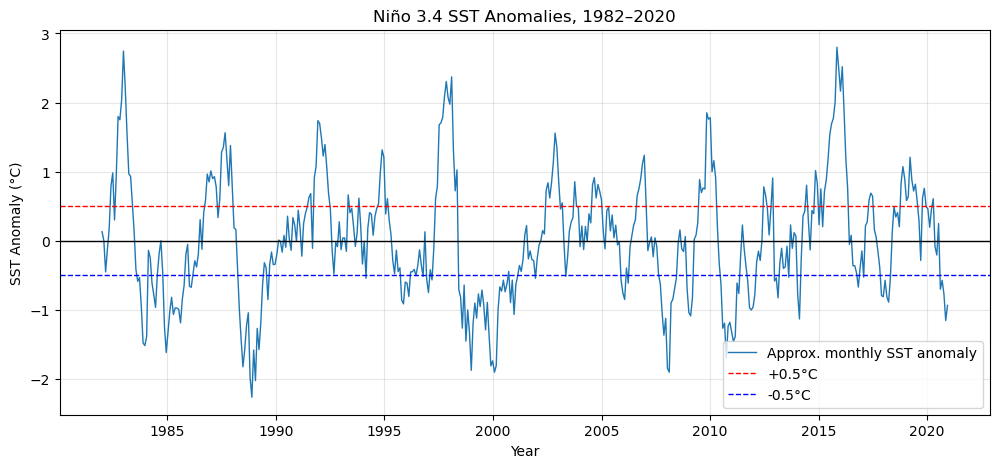

In [9]:
plt.figure(figsize=(12, 5))

nino34_anomaly.plot(label="Approx. monthly SST anomaly", linewidth=1)

plt.axhline(0, color="black", linewidth=1)
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="+0.5°C")
plt.axhline(-0.5, color="blue", linestyle="--", linewidth=1, label="-0.5°C")

plt.title("Niño 3.4 SST Anomalies, 1982–2020")
plt.xlabel("Year")
plt.ylabel("SST Anomaly (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The monthly anomaly time series shows strong year-to-year variability in the Niño 3.4 region. Some years have large positive anomalies, while others have large negative anomalies. This pattern reflects the natural variability of the tropical Pacific.

## Figure 3: Annual Niño 3.4 SST Anomaly and Trend

Finally, I calculate annual mean Niño 3.4 SST anomalies and fit a simple linear trend. This provides a basic way to examine whether the region has warmed over the analysis period.

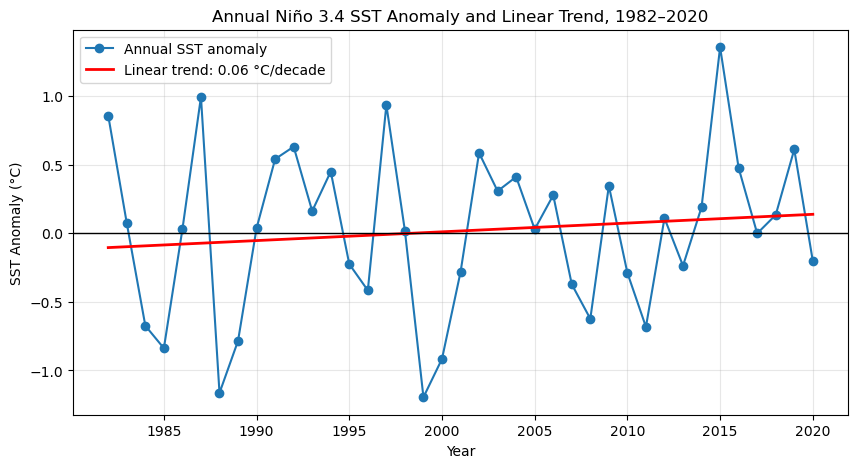

In [10]:
nino34_annual = nino34_anomaly.resample(time="YS").mean()

years = nino34_annual.time.dt.year.values
values = nino34_annual.values

valid = np.isfinite(values)

slope, intercept = np.polyfit(years[valid], values[valid], 1)

trend = slope * years + intercept
trend_per_decade = slope * 10

plt.figure(figsize=(10, 5))

plt.plot(years, values, marker="o", label="Annual SST anomaly")
plt.plot(years, trend, color="red", linewidth=2, label=f"Linear trend: {trend_per_decade:.2f} °C/decade")

plt.axhline(0, color="black", linewidth=1)

plt.title("Annual Niño 3.4 SST Anomaly and Linear Trend, 1982–2020")
plt.xlabel("Year")
plt.ylabel("SST Anomaly (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The annual anomaly plot shows that the Niño 3.4 region has strong interannual variability. The fitted trend provides a simple estimate of long-term change, but the year-to-year fluctuations are much larger than the smooth trend. This suggests that Niño 3.4 SST is strongly influenced by ENSO variability.

## Conclusion

This notebook analyzed SST variability in the Niño 3.4 region using the NOAA OISST dataset. The results show that the region has strong monthly and annual SST anomalies, with repeated warm and cool periods between 1982 and 2020. Although a simple linear trend can be estimated, the main feature of the Niño 3.4 region is strong interannual variability rather than a smooth warming pattern.

One limitation of this analysis is that it only focuses on one ENSO region. A more complete analysis could compare Niño 3.4 with other ENSO regions, such as Niño 3 or Niño 4.